# Kliendisegmentide tarbimismustrite eksploratiivne analüüs

Käesoleva analüüsi eesmärk on uurida kliendisegmentide elektritarbimise mustreid 15-minutilise mõõtesagedusega andmestiku põhjal. Analüüsi käigus võrreldakse segmente päevase ja öise tarbimise, keskmise päevase tarbimise, ööpäevaste tarbimisprofiilide ning tööpäeva ja nädalavahetuse erinevuste lõikes.

Päevaseks tarbimiseks määratletakse ajavahemik 07:00–22:00 ning öiseks tarbimiseks ajavahemik 22:00–07:00.

## 1. Andmete laadimine ja esmane ülevaade

Esimeses etapis imporditakse vajalikud Pythoni teegid ning laaditakse elektritarbimise andmestik CSV-failist. Seejärel vaadeldakse andmestiku esimesi ridu, veergude andmetüüpe, puuduvate väärtuste olemasolu ning tarbimist kirjeldavat statistikat.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r"C:\Users\jaana\Documents\final-project\DataSources\real_electricity_consumption_sorted.csv"

df = pd.read_csv(file_path)

df.head()

,household_id,timestamp,date,time,consumption_kwh
0,s-1,01.04.2025 00:00:00,01.04.2025,00:00:00,0.026
1,s-1,01.04.2025 00:15:00,01.04.2025,00:15:00,0.063
2,s-1,01.04.2025 00:30:00,01.04.2025,00:30:00,0.021
3,s-1,01.04.2025 00:45:00,01.04.2025,00:45:00,0.028
4,s-1,01.04.2025 01:00:00,01.04.2025,01:00:00,0.013


In [ ]:

import holidays

estonian_holidays = holidays.Estonia(years=[2025, 2026])

#Converting the "timestamp" column values from str to datetime data type

df_consumption["timestamp"] = pd.to_datetime(df_consumption["timestamp"], dayfirst = True)



#Adding an hour column to the dataframes

df_consumption["hour"] = df_consumption["timestamp"].dt.hour



#Adding a new column to check if it's daytime (between 7:00 and 22:00)

df_consumption["is_daytime"] = (df_consumption["hour"] >= 7) & (df_consumption["hour"] < 22)



#Adding a day column to the dataframes

df_consumption["day_of_week"] = df_consumption["timestamp"].dt.dayofweek



#Adding a new column to check if it's weekend (Saturday or Sunday)

df_consumption["is_weekend"] = (df_consumption["day_of_week"] >= 5)



#Adding a new column to check if it's Estonian national holiday

df_consumption['is_public_holiday'] = df_consumption['timestamp'].dt.date.isin(estonian_holidays)



#Adding a new column to check if it's required to use night rate (between 22:00 and 7:00, whole weekends and national holidays)

df_consumption['is_night_rate'] = ~df_consumption['is_daytime'] | df_consumption['is_weekend'] | df_consumption['is_public_holiday']

NameError: name 'df_consumption' is not defined

In [7]:
file_path = r"C:\Users\jaana\Downloads\real_electricity_consumption_sorted.csv"

In [9]:
file_path = r"C:\Users\jaana\Documents\final-project\DataSources\real_electricity_consumption_sorted.csv"


df = pd.read_csv(file_path)

df.head()

,household_id,timestamp,date,time,consumption_kwh
0,s-1,01.04.2025 00:00:00,01.04.2025,00:00:00,0.026
1,s-1,01.04.2025 00:15:00,01.04.2025,00:15:00,0.063
2,s-1,01.04.2025 00:30:00,01.04.2025,00:30:00,0.021
3,s-1,01.04.2025 00:45:00,01.04.2025,00:45:00,0.028
4,s-1,01.04.2025 01:00:00,01.04.2025,01:00:00,0.013


In [10]:
import os

print(os.path.exists(file_path))

True


In [11]:
df.head()


,household_id,timestamp,date,time,consumption_kwh
0,s-1,01.04.2025 00:00:00,01.04.2025,00:00:00,0.026
1,s-1,01.04.2025 00:15:00,01.04.2025,00:15:00,0.063
2,s-1,01.04.2025 00:30:00,01.04.2025,00:30:00,0.021
3,s-1,01.04.2025 00:45:00,01.04.2025,00:45:00,0.028
4,s-1,01.04.2025 01:00:00,01.04.2025,01:00:00,0.013


In [12]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1264608 entries, 0 to 1264607
Data columns (total 5 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   household_id     1264608 non-null  str    
 1   timestamp        1264608 non-null  str    
 2   date             1264608 non-null  str    
 3   time             1264608 non-null  str    
 4   consumption_kwh  1264608 non-null  float64
dtypes: float64(1), str(4)
memory usage: 96.9 MB


In [13]:
df.isna().sum()

household_id       0
timestamp          0
date               0
time               0
consumption_kwh    0
dtype: int64

In [14]:
df["consumption_kwh"].describe()

count    1.264608e+06
mean     2.854280e-01
std      5.499659e-01
min      0.000000e+00
25%      9.000000e-03
50%      7.700000e-02
75%      3.270000e-01
max      6.963000e+00
Name: consumption_kwh, dtype: float64

In [15]:
df.columns

Index(['household_id', 'timestamp', 'date', 'time', 'consumption_kwh'], dtype='str')

## 2. Andmete ettevalmistamine

Järgmises etapis teisendatakse ajatempel kuupäeva ja kellaaja formaati ning luuakse analüüsiks vajalikud lisatunnused. Nendeks on kuupäev, tund, kellaaeg, nädalapäev, nädalavahetuse tunnus ning 15-minutiline ajaslott. Lisaks tuvastatakse kliendisegment `household_id` tunnuse alguse põhjal.

In [16]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    format="%d.%m.%Y %H:%M:%S"
)

df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["time"] = df["timestamp"].dt.strftime("%H:%M")

df["weekday_num"] = df["timestamp"].dt.weekday
df["weekday"] = df["timestamp"].dt.day_name()
df["is_weekend"] = df["weekday_num"] >= 5

df["slot"] = df["hour"] * 4 + df["minute"] // 15

df["segment"] = (
    df["household_id"]
    .astype(str)
    .str.extract(r"^([A-Za-z]+)", expand=False)
    .str.lower()
)

df.head()

,household_id,timestamp,date,time,consumption_kwh,hour,minute,weekday_num,weekday,is_weekend,slot,segment
0,s-1,2025-04-01 00:00:00,2025-04-01,00:00,0.026,0,0,1,Tuesday,False,0,s
1,s-1,2025-04-01 00:15:00,2025-04-01,00:15,0.063,0,15,1,Tuesday,False,1,s
2,s-1,2025-04-01 00:30:00,2025-04-01,00:30,0.021,0,30,1,Tuesday,False,2,s
3,s-1,2025-04-01 00:45:00,2025-04-01,00:45,0.028,0,45,1,Tuesday,False,3,s
4,s-1,2025-04-01 01:00:00,2025-04-01,01:00,0.013,1,0,1,Tuesday,False,4,s


In [33]:
segment_order = ["s", "m", "l", "xl"]

df["segment"] = pd.Categorical(
    df["segment"],
    categories=segment_order,
    ordered=True
)

### Päevase ja öise tarbimise määratlemine

Analüüsis määratletakse päevaseks tarbimiseks ajavahemik 07:00–22:00. Öiseks tarbimiseks loetakse ajavahemik 22:00–07:00. Selle alusel luuakse uus tunnus, mis võimaldab võrrelda segmentide päevast ja öist tarbimiskäitumist.

In [34]:
df["period"] = np.where(
    (df["hour"] >= 7) & (df["hour"] < 22),
    "day",
    "night"
)

df[["timestamp", "hour", "time", "period", "household_id", "segment", "consumption_kwh"]].head()

,timestamp,hour,time,period,household_id,segment,consumption_kwh
0,2025-04-01 00:00:00,0,00:00,night,s-1,s,0.026
1,2025-04-01 00:15:00,0,00:15,night,s-1,s,0.063
2,2025-04-01 00:30:00,0,00:30,night,s-1,s,0.021
3,2025-04-01 00:45:00,0,00:45,night,s-1,s,0.028
4,2025-04-01 01:00:00,1,01:00,night,s-1,s,0.013


## 3. Customer segments overview

Before comparing consumption patterns, the number of customers in each segment is examined. This helps to understand the structure of the dataset and whether the customer segments are represented equally.

In [35]:
segment_counts = (
    df.groupby("segment")["household_id"]
    .nunique()
    .reset_index(name="number_of_customers")
)

segment_counts

,segment,number_of_customers
0,s,10
1,m,10
2,l,10
3,xl,10


## 4. Keskmine päevane tarbimine kliendisegmentide lõikes

Selles etapis agregeeritakse 15-minutilised elektritarbimise mõõtmised kliendi ja päeva tasemele. See võimaldab võrrelda kliendisegmente nende keskmise päevase elektritarbimise põhjal.

Päevane tarbimine arvutatakse iga kliendi ja iga kuupäeva kohta eraldi. Seejärel leitakse iga kliendisegmendi kohta keskmine, mediaan, miinimum, maksimum ja standardhälve.

In [36]:
daily_client = (
    df.groupby(["segment", "household_id", "date"])["consumption_kwh"]
    .sum()
    .reset_index(name="daily_kwh")
)

daily_client.head()

,segment,household_id,date,daily_kwh
0,s,s-1,2025-04-01,0.667
1,s,s-1,2025-04-02,0.557
2,s,s-1,2025-04-03,0.573
3,s,s-1,2025-04-04,0.768
4,s,s-1,2025-04-05,0.586


### Segmentide päevase tarbimise kokkuvõte

Järgnevas tabelis on esitatud iga kliendisegmendi päevase tarbimise kirjeldavad näitajad. Keskmine väärtus näitab tüüpilist päevast tarbimist, mediaan aitab hinnata keskset taset ning standardhälve näitab tarbimise varieeruvust segmendi sees.

In [37]:
segment_daily_summary = (
    daily_client.groupby("segment")
    .agg(
        avg_daily_kwh=("daily_kwh", "mean"),
        median_daily_kwh=("daily_kwh", "median"),
        min_daily_kwh=("daily_kwh", "min"),
        max_daily_kwh=("daily_kwh", "max"),
        std_daily_kwh=("daily_kwh", "std")
    )
    .reset_index()
)

segment_daily_summary

,segment,avg_daily_kwh,median_daily_kwh,min_daily_kwh,max_daily_kwh,std_daily_kwh
0,s,11.832087,4.3020,0.000,190.402,21.672540
1,m,17.391465,10.9055,0.294,116.139,17.565689
2,l,28.485442,22.1200,0.450,192.475,21.653495
3,xl,51.956069,43.6410,0.314,231.663,36.299198


Graafik näitab, kuidas keskmine päevane elektritarbimine erineb kliendisegmentide lõikes. Kõrgema keskmise tarbimisega segmendid kasutavad ühe kliendi kohta päevas rohkem elektrienergiat, samas kui madalama väärtusega segmendid on väiksema tarbimismahuga.

### Päevase tarbimise jaotus segmentide lõikes

Lisaks keskmisele väärtusele on oluline vaadelda ka päevase tarbimise jaotust segmendi sees. Boxplot ehk karpdiagramm aitab hinnata, kui palju klientide päevane tarbimine segmendi sees varieerub ning kas esineb võimalikke erindväärtusi.

<Figure size 800x500 with 0 Axes>

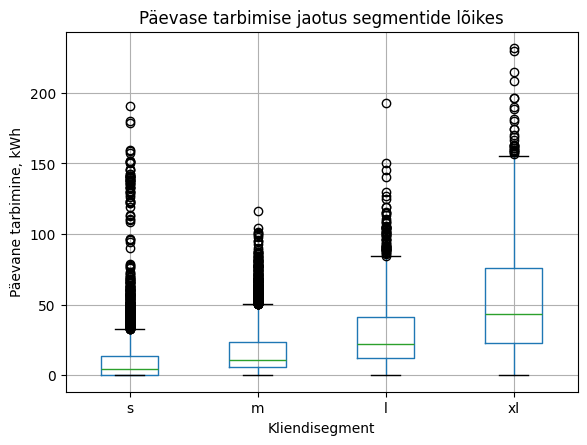

In [38]:
plt.figure(figsize=(8, 5))

daily_client.boxplot(
    column="daily_kwh",
    by="segment"
)

plt.xlabel("Kliendisegment")
plt.ylabel("Päevane tarbimine, kWh")
plt.title("Päevase tarbimise jaotus segmentide lõikes")
plt.suptitle("")
plt.show()

Karpdiagramm näitab päevase elektritarbimise jaotust iga kliendisegmendi sees. Laiem kast või pikemad vurrud viitavad suuremale varieeruvusele. See tähendab, et sama segmendi klientide tarbimiskäitumine võib olla erinev.

## 5. Päevase ja öise tarbimise võrdlus

Selles etapis võrreldakse kliendisegmentide elektritarbimist päevase ja öise perioodi lõikes. Päevaseks tarbimiseks on määratletud ajavahemik 07:00–22:00 ning öiseks tarbimiseks ajavahemik 22:00–07:00.

Selline jaotus aitab hinnata, kas tarbimine toimub peamiselt aktiivsel päevasel ajal või on mõnes segmendis suurem osakaal ka öisel tarbimisel.

In [39]:
day_night_summary = (
    df.groupby(["segment", "period"])["consumption_kwh"]
    .sum()
    .reset_index()
)

day_night_summary

,segment,period,consumption_kwh
0,s,day,17203.099
1,s,night,22316.070
2,m,day,29378.840
3,m,night,28708.652
4,l,day,50279.541
5,l,night,39535.058
6,xl,day,82519.475
7,xl,night,91013.795


### Päevase ja öise tarbimise osakaal

Järgnevalt arvutatakse, kui suur osa iga segmendi kogutarbimisest toimub päevasel ja öisel perioodil. Osakaalude kasutamine võimaldab segmente võrrelda ka siis, kui nende kogutarbimise maht on erinev.

In [40]:
day_night_summary["share"] = (
    day_night_summary["consumption_kwh"] /
    day_night_summary.groupby("segment")["consumption_kwh"].transform("sum")
)

day_night_summary

,segment,period,consumption_kwh,share
0,s,day,17203.099,0.435310
1,s,night,22316.070,0.564690
2,m,day,29378.840,0.505769
3,m,night,28708.652,0.494231
4,l,day,50279.541,0.559815
5,l,night,39535.058,0.440185
6,xl,day,82519.475,0.475525
7,xl,night,91013.795,0.524475


In [41]:
day_night_pivot = day_night_summary.pivot(
    index="segment",
    columns="period",
    values="share"
).reset_index()

day_night_pivot

period,segment,day,night
0,s,0.435310,0.564690
1,m,0.505769,0.494231
2,l,0.559815,0.440185
3,xl,0.475525,0.524475


### Päevase ja öise tarbimise osakaalu graafik

Järgneval graafikul on esitatud päevase ja öise tarbimise osakaal iga kliendisegmendi kogutarbimisest.

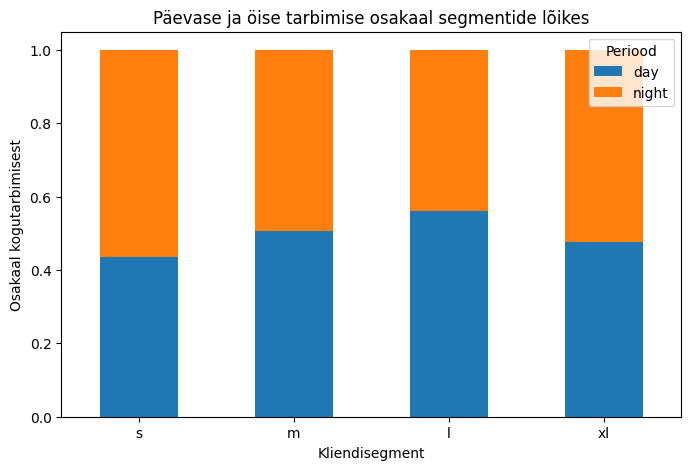

In [42]:
day_night_plot = day_night_summary.pivot(
    index="segment",
    columns="period",
    values="share"
)

day_night_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.xlabel("Kliendisegment")
plt.ylabel("Osakaal kogutarbimisest")
plt.title("Päevase ja öise tarbimise osakaal segmentide lõikes")
plt.xticks(rotation=0)
plt.legend(title="Periood")
plt.show()


Graafik näitab, kui suur osa iga kliendisegmendi elektritarbimisest toimub päevasel ja öisel perioodil. Suurem päevase tarbimise osakaal viitab sellele, et tarbimine on rohkem koondunud ajavahemikku 07:00–22:00. Suurem öise tarbimise osakaal võib viidata ühtlasemale tarbimisele või suuremale tarbimisele öisel ajal.

### Päevase ja öise tarbimise suhe

Lisaks osakaaludele arvutatakse päevase ja öise tarbimise suhe. See näitab, mitu korda suurem on segmendi päevane tarbimine võrreldes öise tarbimisega.

In [43]:
day_night_ratio = day_night_summary.pivot(
    index="segment",
    columns="period",
    values="consumption_kwh"
).reset_index()

day_night_ratio["day_to_night_ratio"] = (
    day_night_ratio["day"] / day_night_ratio["night"]
)

day_night_ratio

period,segment,day,night,day_to_night_ratio
0,s,17203.099,22316.070,0.770884
1,m,29378.840,28708.652,1.023344
2,l,50279.541,39535.058,1.271771
3,xl,82519.475,91013.795,0.906670


Tabelist selgub, et segmentide päevase ja öise tarbimise suhe erineb. Segmendis `s` on päevase ja öise tarbimise suhe 0,77, mis tähendab, et öine tarbimine on suurem kui päevane tarbimine. Segmendis `m` on vastav suhe 1,02, mis viitab üsna ühtlasele jaotusele päevase ja öise perioodi vahel. Segmendis `l` on päevane tarbimine öisest suurem, kuna päevase ja öise tarbimise suhe on 1,27. Segmendis `xl` on suhe 0,91, mis tähendab, et öine tarbimine on veidi suurem kui päevane tarbimine.

Kokkuvõttes eristub segment `l` kõige selgema päevase tarbimise ülekaaluga, samas kui segmentides `s` ja `xl` on öise tarbimise osakaal suurem. Segment `m` paikneb nende vahel ning selle tarbimine jaguneb päeva ja öö vahel peaaegu võrdselt.

In [44]:
day_night_ratio["day_share"] = (
    day_night_ratio["day"] / 
    (day_night_ratio["day"] + day_night_ratio["night"])
)

day_night_ratio["night_share"] = (
    day_night_ratio["night"] / 
    (day_night_ratio["day"] + day_night_ratio["night"])
)

day_night_ratio

period,segment,day,night,day_to_night_ratio,day_share,night_share
0,s,17203.099,22316.070,0.770884,0.435310,0.564690
1,m,29378.840,28708.652,1.023344,0.505769,0.494231
2,l,50279.541,39535.058,1.271771,0.559815,0.440185
3,xl,82519.475,91013.795,0.906670,0.475525,0.524475


In [45]:
day_night_ratio_display = day_night_ratio.copy()

day_night_ratio_display["day_share"] = (
    day_night_ratio_display["day_share"] * 100
).round(1)

day_night_ratio_display["night_share"] = (
    day_night_ratio_display["night_share"] * 100
).round(1)

day_night_ratio_display["day_to_night_ratio"] = (
    day_night_ratio_display["day_to_night_ratio"]
).round(2)

day_night_ratio_display

period,segment,day,night,day_to_night_ratio,day_share,night_share
0,s,17203.099,22316.070,0.77,43.5,56.5
1,m,29378.840,28708.652,1.02,50.6,49.4
2,l,50279.541,39535.058,1.27,56.0,44.0
3,xl,82519.475,91013.795,0.91,47.6,52.4


Päevase ja öise tarbimise osakaalude põhjal on näha, et segment `l` kasutab suurema osa elektrist päevasel ajal. Segmentides `s` ja `xl` on öise tarbimise osakaal suurem kui päevase tarbimise osakaal. Segment `m` on kõige ühtlasema jaotusega, kuna päevane ja öine tarbimine moodustavad peaaegu võrdse osa kogutarbimisest.

## 6. Ööpäevane 15-minutiline tarbimisprofiil

Selles etapis koostatakse kliendisegmentide tüüpiline ööpäevane tarbimisprofiil. Kuna andmestik sisaldab 15-minutilise sagedusega mõõtmisi, arvutatakse iga segmendi kohta keskmine tarbimine igas 15-minutilises ajavahemikus.

Selline profiil võimaldab hinnata, millistel kellaaegadel on tarbimine suurem või väiksem ning kas segmentide vahel esineb erinevusi tarbimise ajastuses.

In [46]:

profile_15min = (
    df.groupby(["segment", "slot", "time"])["consumption_kwh"]
    .mean()
    .reset_index(name="avg_15min_kwh")
    .sort_values(["segment", "slot"])
)

profile_15min.head()

,segment,slot,time,avg_15min_kwh
0,s,0,00:00,0.174565
1,s,1,00:15,0.202501
2,s,2,00:30,0.237433
3,s,3,00:45,0.244257
4,s,4,01:00,0.209907


### Segmentide keskmine ööpäevane tarbimisprofiil

Järgneval graafikul on esitatud iga kliendisegmendi keskmine 15-minutiline tarbimine ööpäeva jooksul.

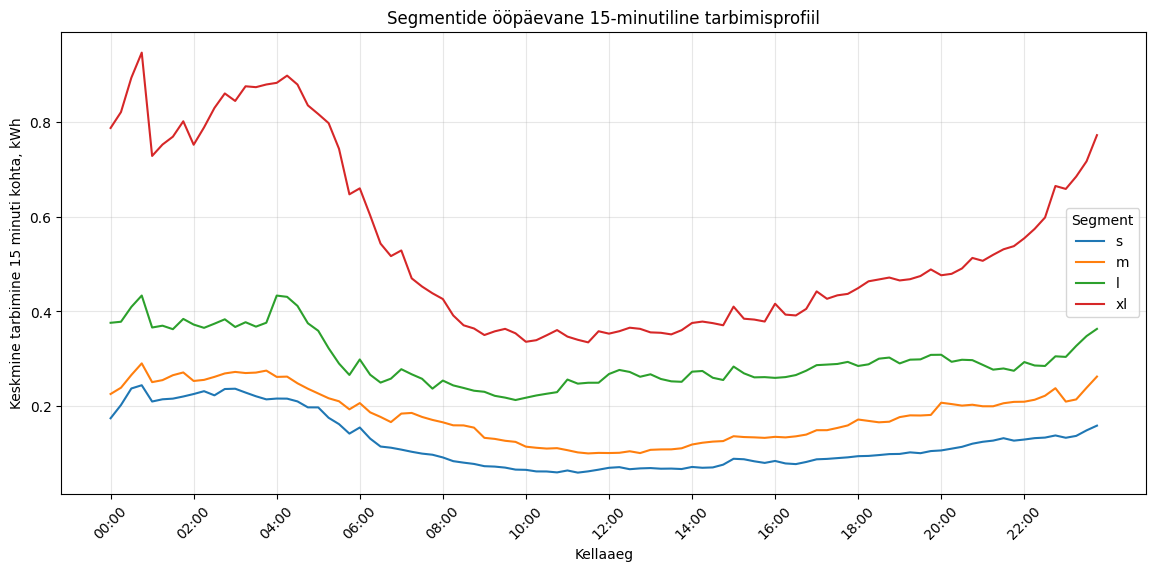

In [47]:
plt.figure(figsize=(14, 6))

for segment in segment_order:
    data = profile_15min[profile_15min["segment"] == segment]
    plt.plot(
        data["slot"],
        data["avg_15min_kwh"],
        label=segment
    )

tick_slots = list(range(0, 96, 8))
tick_labels = [f"{slot // 4:02d}:00" for slot in tick_slots]

plt.xticks(tick_slots, tick_labels, rotation=45)
plt.xlabel("Kellaaeg")
plt.ylabel("Keskmine tarbimine 15 minuti kohta, kWh")
plt.title("Segmentide ööpäevane 15-minutiline tarbimisprofiil")
plt.legend(title="Segment")
plt.grid(True, alpha=0.3)
plt.show()

Graafikult on näha, et segmentide ööpäevased tarbimisprofiilid erinevad peamiselt tarbimismahu poolest. Kõige suurema keskmise 15-minutilise tarbimisega on segment `xl`, mille tarbimine on kogu ööpäeva jooksul teistest segmentidest selgelt kõrgem. Sellele järgnevad segmendid `l`, `m` ja `s`.

Kõigi segmentide puhul on märgatav kõrgem tarbimine öisel ajal ning varahommikul. Seejärel tarbimine langeb hommikupoolikul ning saavutab madalama taseme ligikaudu kella 09:00–11:00 vahel. Pärastlõunal ja õhtul hakkab tarbimine taas järk-järgult suurenema.

Segment `xl` eristub kõige tugevamalt, kuna selle tarbimiskõver on nii taseme kui ka kõikumise poolest kõige suurem. Segmendid `s` ja `m` on madalama tarbimistasemega ning nende ööpäevane profiil on ühtlasem.

### Tippkoormuse aja leidmine

Tippkoormuse ajaks loetakse selles analüüsis kellaaeg, mil segmendi keskmine 15-minutiline tarbimine on kõige suurem. Tippkoormuse aeg aitab kirjeldada, millal segmentide elektritarbimine on ööpäeva jooksul kõige intensiivsem.

In [48]:
peak_times = (
    profile_15min.loc[
        profile_15min.groupby("segment")["avg_15min_kwh"].idxmax()
    ][["segment", "time", "avg_15min_kwh"]]
    .rename(columns={
        "time": "peak_time",
        "avg_15min_kwh": "peak_avg_15min_kwh"
    })
    .reset_index(drop=True)
)

peak_times

,segment,peak_time,peak_avg_15min_kwh
0,s,00:45,0.244257
1,m,00:45,0.290382
2,l,00:45,0.433627
3,xl,00:45,0.946426


## 7. Tööpäeva ja nädalavahetuse tarbimise võrdlus

Selles etapis võrreldakse kliendisegmentide elektritarbimist tööpäevadel ja nädalavahetustel. Selleks kasutatakse varem loodud tunnust `is_weekend`, mille väärtus näitab, kas mõõtmine toimus nädalavahetusel või mitte.

Võrdlus aitab hinnata, kas klientide tarbimiskäitumine muutub nädalavahetustel võrreldes tööpäevadega.

In [49]:
weekday_weekend = (
    df.groupby(["segment", "household_id", "date", "is_weekend"])["consumption_kwh"]
    .sum()
    .reset_index(name="daily_kwh")
)

weekday_weekend.head()

,segment,household_id,date,is_weekend,daily_kwh
0,s,s-1,2025-04-01,False,0.667
1,s,s-1,2025-04-02,False,0.557
2,s,s-1,2025-04-03,False,0.573
3,s,s-1,2025-04-04,False,0.768
4,s,s-1,2025-04-05,True,0.586


### Keskmine päevane tarbimine tööpäeval ja nädalavahetusel

Järgnevalt leitakse iga kliendisegmendi keskmine päevane tarbimine eraldi tööpäevade ja nädalavahetuste kohta.

In [51]:
weekday_weekend_summary = (
    weekday_weekend.groupby(["segment", "is_weekend"])["daily_kwh"]
    .mean()
    .reset_index()
)

weekday_weekend_summary["day_type"] = np.where(
    weekday_weekend_summary["is_weekend"],
    "weekend",
    "weekday"
)

weekday_weekend_summary


,segment,is_weekend,daily_kwh,day_type
0,s,False,11.636096,weekday
1,s,True,12.325158,weekend
2,m,False,17.008487,weekday
3,m,True,18.354957,weekend
4,l,False,27.182764,weekday
5,l,True,31.761744,weekend
6,xl,False,50.507162,weekday
7,xl,True,55.601214,weekend


In [52]:
weekday_weekend_pivot = weekday_weekend_summary.pivot(
    index="segment",
    columns="day_type",
    values="daily_kwh"
).reindex(segment_order)

weekday_weekend_pivot

day_type,weekday,weekend
segment,,
s,11.636096,12.325158
m,17.008487,18.354957
l,27.182764,31.761744
xl,50.507162,55.601214


In [53]:
weekday_weekend_pivot["weekend_to_weekday_ratio"] = (
    weekday_weekend_pivot["weekend"] /
    weekday_weekend_pivot["weekday"]
)

weekday_weekend_pivot

day_type,weekday,weekend,weekend_to_weekday_ratio
segment,,,
s,11.636096,12.325158,1.059218
m,17.008487,18.354957,1.079165
l,27.182764,31.761744,1.168452
xl,50.507162,55.601214,1.100858


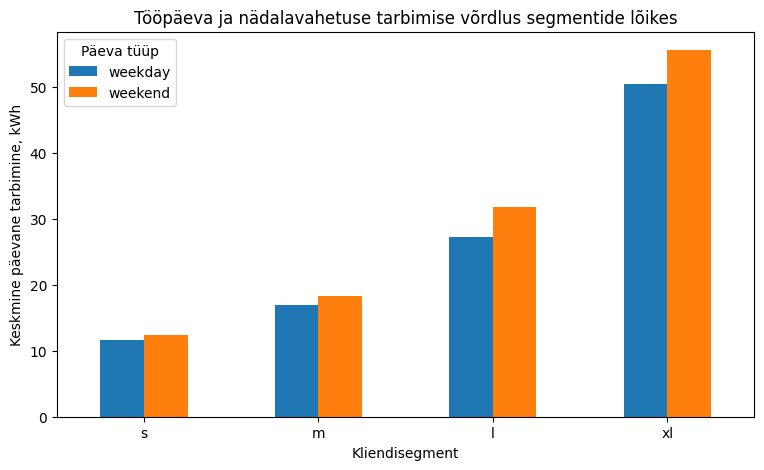

In [54]:
weekday_weekend_pivot[["weekday", "weekend"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Kliendisegment")
plt.ylabel("Keskmine päevane tarbimine, kWh")
plt.title("Tööpäeva ja nädalavahetuse tarbimise võrdlus segmentide lõikes")
plt.xticks(rotation=0)
plt.legend(title="Päeva tüüp")
plt.show()

Graafikult on näha, et kõigis kliendisegmentides on keskmine päevane elektritarbimine nädalavahetusel (`weekend`) suurem kui tööpäevadel (`weekday`). See viitab sellele, et klientide elektritarbimine suureneb nädalavahetustel, mis võib olla seotud suurema koduse aktiivsusega.

Segmentide võrdluses suureneb tarbimismaht vastavalt segmendi suurusele: kõige madalam tarbimine on segmendis `s` ning kõige kõrgem segmendis `xl`. Kõige suurem absoluutne erinevus tööpäeva ja nädalavahetuse vahel paistab olevat segmendis `l` ja `xl`, kus nädalavahetuse tarbimine on tööpäevaga võrreldes märgatavalt kõrgem.


## 8. Kuupõhine tarbimistrend

Selles etapis vaadeldakse kliendisegmentide tarbimise muutumist ajas. Selleks agregeeritakse elektritarbimine kliendi, päeva ja kuu tasemele ning arvutatakse iga segmendi kohta keskmine päevane tarbimine kuude lõikes.

Kuupõhine trend aitab hinnata, kas tarbimises esineb ajas muutusi, näiteks hooajalisust või üldist tarbimise kasvu või langust.

In [57]:
df["month"] = df["timestamp"].dt.to_period("M").astype(str)

df[["timestamp", "month"]].head()

,timestamp,month
0,2025-04-01 00:00:00,2025-04
1,2025-04-01 00:15:00,2025-04
2,2025-04-01 00:30:00,2025-04
3,2025-04-01 00:45:00,2025-04
4,2025-04-01 01:00:00,2025-04


In [58]:
monthly_trend = (
    df.groupby(["segment", "household_id", "month", "date"])["consumption_kwh"]
    .sum()
    .reset_index(name="daily_kwh")
    .groupby(["segment", "month"])
    .agg(
        avg_daily_kwh=("daily_kwh", "mean")
    )
    .reset_index()
)

monthly_trend.head()

,segment,month,avg_daily_kwh
0,s,2025-04,4.117587
1,s,2025-05,2.907361
2,s,2025-06,3.829490
3,s,2025-07,3.391668
4,s,2025-08,4.013039


### Keskmine päevane tarbimine kuude lõikes

Järgneval graafikul on esitatud kliendisegmentide keskmine päevane elektritarbimine kuude lõikes.

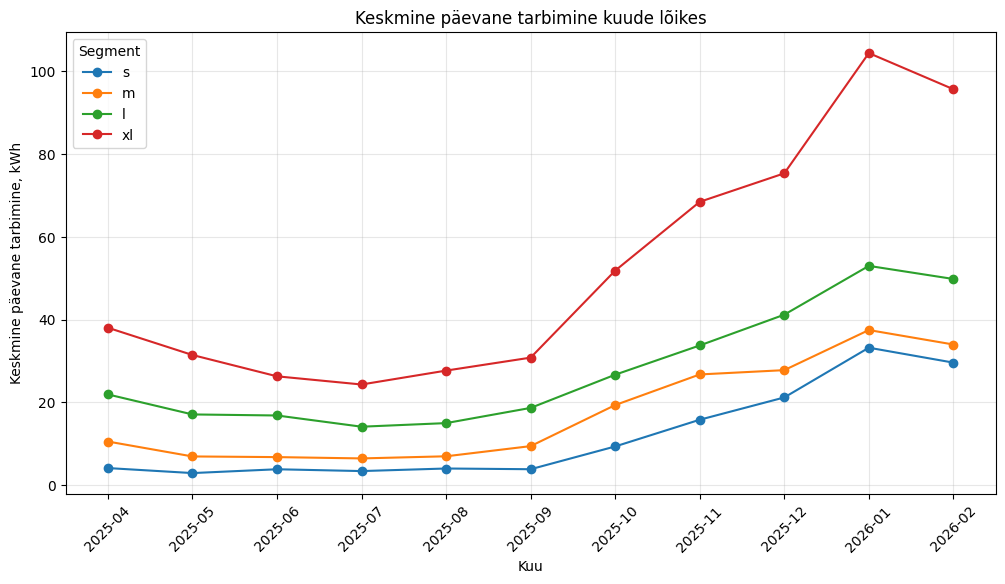

In [59]:
plt.figure(figsize=(12, 6))

for segment in segment_order:
    data = monthly_trend[monthly_trend["segment"] == segment]
    plt.plot(
        data["month"],
        data["avg_daily_kwh"],
        marker="o",
        label=segment
    )

plt.xlabel("Kuu")
plt.ylabel("Keskmine päevane tarbimine, kWh")
plt.title("Keskmine päevane tarbimine kuude lõikes")
plt.xticks(rotation=45)
plt.legend(title="Segment")
plt.grid(True, alpha=0.3)
plt.show()

Graafikult on näha, et kõigi kliendisegmentide keskmine päevane elektritarbimine muutub kuude lõikes sarnases suunas. Kevad- ja suvekuudel on tarbimine madalam, samas kui sügisel ja talvel hakkab tarbimine suurenema. Kõige kõrgem keskmine päevane tarbimine esineb jaanuaris 2026.

Segmentide järjestus püsib kogu perioodi jooksul sarnane: kõige suurema tarbimisega on segment `xl`, millele järgnevad `l`, `m` ja `s`. See näitab, et segmentide vahelised erinevused on stabiilsed ka ajas.

Kõige tugevam kasv on nähtav segmendis `xl`, kus tarbimine suureneb märgatavalt alates sügiskuudest. Sarnane, kuid väiksema mahuga kasv on näha ka segmentides `l`, `m` ja `s`. Selline muster võib viidata hooajalisusele, näiteks suuremale elektritarbimisele külmematel kuudel.

## 9. Segmentide tarbimise varieeruvus

Selles etapis hinnatakse, kui palju klientide päevane elektritarbimine segmentide sees kõigub. Selleks arvutatakse iga kliendi kohta keskmine päevane tarbimine ja standardhälve. Seejärel leitakse variatsioonikordaja, mis näitab tarbimise suhtelist muutlikkust.

Variatsioonikordaja arvutatakse standardhälbe ja keskmise tarbimise suhtena. Mida suurem on variatsioonikordaja, seda rohkem kliendi päevane tarbimine kõigub.

In [60]:
client_variability = (
    daily_client.groupby(["segment", "household_id"])
    .agg(
        avg_daily_kwh=("daily_kwh", "mean"),
        std_daily_kwh=("daily_kwh", "std")
    )
    .reset_index()
)

client_variability["cv"] = (
    client_variability["std_daily_kwh"] /
    client_variability["avg_daily_kwh"]
)

client_variability.head()

,segment,household_id,avg_daily_kwh,std_daily_kwh,cv
0,s,s-1,10.638392,14.122468,1.327500
1,s,s-10,7.577075,10.740722,1.417529
2,s,s-2,5.702641,7.243958,1.270281
3,s,s-3,0.248251,0.094791,0.381834
4,s,s-4,42.484907,45.834875,1.078851


### Varieeruvuse kokkuvõte segmentide lõikes

Järgnevalt arvutatakse iga segmendi kohta keskmine ja mediaan variatsioonikordaja. See võimaldab võrrelda, millistes segmentides on tarbimine stabiilsem ja millistes rohkem kõikuv.

In [61]:
segment_variability = (
    client_variability.groupby("segment")
    .agg(
        avg_cv=("cv", "mean"),
        median_cv=("cv", "median")
    )
    .reset_index()
)

segment_variability["segment"] = pd.Categorical(
    segment_variability["segment"],
    categories=segment_order,
    ordered=True
)

segment_variability = segment_variability.sort_values("segment").reset_index(drop=True)

segment_variability

,segment,avg_cv,median_cv
0,s,1.256816,1.291194
1,m,0.818684,0.780771
2,l,0.692434,0.674497
3,xl,0.663910,0.623597


### Keskmine variatsioonikordaja segmentide lõikes

Järgneval graafikul võrreldakse segmentide keskmist variatsioonikordajat. Kõrgem väärtus näitab suuremat suhtelist kõikumist päevases tarbimises.

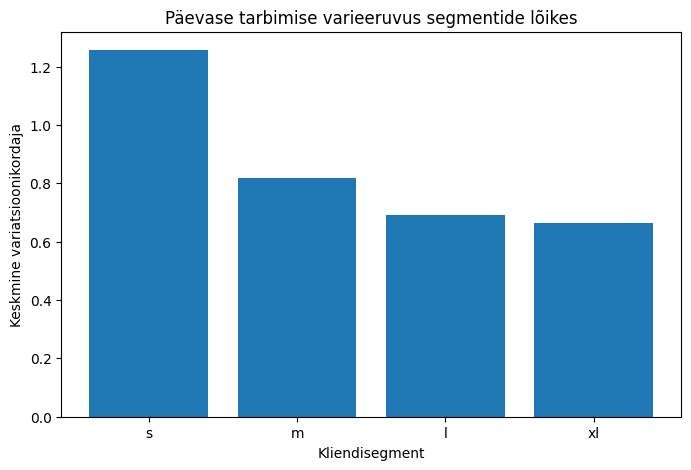

In [62]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_variability["segment"],
    segment_variability["avg_cv"]
)

plt.xlabel("Kliendisegment")
plt.ylabel("Keskmine variatsioonikordaja")
plt.title("Päevase tarbimise varieeruvus segmentide lõikes")
plt.show()

Graafikult on näha, et kõige suurem keskmine variatsioonikordaja on segmendis `s`. See tähendab, et selle segmendi klientide päevane tarbimine kõigub suhteliselt rohkem võrreldes nende keskmise päevase tarbimisega.

Segmentides `m`, `l` ja `xl` on variatsioonikordaja madalam, mis viitab stabiilsemale tarbimismustrile. Kõige väiksem varieeruvus on segmendis `xl`, mis tähendab, et suurema tarbimismahuga klientide tarbimine on päevade lõikes suhteliselt ühtlasem.

Tulemus näitab, et väiksema tarbimismahuga kliendid võivad olla käitumiselt ebastabiilsemad, samas kui suurema tarbimismahuga segmentides on tarbimine regulaarsem.

## 10. Lõplik kokkuvõttetabel

Analüüsi viimases etapis koondatakse olulisemad segmendipõhised näitajad ühte tabelisse. Kokkuvõttetabel sisaldab keskmist päevast tarbimist, mediaantarbimist, tarbimise varieeruvust, tippkoormuse aega ning päevase ja öise tarbimise suhet.

Selline tabel annab tervikliku ülevaate kliendisegmentide peamistest tarbimismustritest.

In [64]:
final_summary = (
    segment_daily_summary
    .merge(peak_times, on="segment", how="left")
    .merge(segment_variability, on="segment", how="left")
    .merge(
        day_night_ratio[["segment", "day", "night", "day_to_night_ratio"]],
        on="segment",
        how="left"
    )
)

final_summary["segment"] = pd.Categorical(
    final_summary["segment"],
    categories=segment_order,
    ordered=True
)

final_summary = final_summary.sort_values("segment").reset_index(drop=True)

final_summary

,segment,avg_daily_kwh,median_daily_kwh,min_daily_kwh,max_daily_kwh,std_daily_kwh,peak_time,peak_avg_15min_kwh,avg_cv,median_cv,day,night,day_to_night_ratio
0,s,11.832087,4.3020,0.000,190.402,21.672540,00:45,0.244257,1.256816,1.291194,17203.099,22316.070,0.770884
1,m,17.391465,10.9055,0.294,116.139,17.565689,00:45,0.290382,0.818684,0.780771,29378.840,28708.652,1.023344
2,l,28.485442,22.1200,0.450,192.475,21.653495,00:45,0.433627,0.692434,0.674497,50279.541,39535.058,1.271771
3,xl,51.956069,43.6410,0.314,231.663,36.299198,00:45,0.946426,0.663910,0.623597,82519.475,91013.795,0.906670


In [65]:
final_summary_display = final_summary.copy()

numeric_columns = final_summary_display.select_dtypes(include="number").columns

final_summary_display[numeric_columns] = final_summary_display[numeric_columns].round(2)

final_summary_display

,segment,avg_daily_kwh,median_daily_kwh,min_daily_kwh,max_daily_kwh,std_daily_kwh,peak_time,peak_avg_15min_kwh,avg_cv,median_cv,day,night,day_to_night_ratio
0,s,11.83,4.30,0.00,190.40,21.67,00:45,0.24,1.26,1.29,17203.10,22316.07,0.77
1,m,17.39,10.91,0.29,116.14,17.57,00:45,0.29,0.82,0.78,29378.84,28708.65,1.02
2,l,28.49,22.12,0.45,192.48,21.65,00:45,0.43,0.69,0.67,50279.54,39535.06,1.27
3,xl,51.96,43.64,0.31,231.66,36.30,00:45,0.95,0.66,0.62,82519.48,91013.80,0.91


Kokkuvõttetabel koondab kliendisegmentide peamised tarbimismustrid. Tabelist on näha, et keskmine päevane elektritarbimine suureneb segmentide järjestuses `s`, `m`, `l` ja `xl`. Segment `s` tarbib keskmiselt 11,83 kWh päevas, samas kui segment `xl` tarbib keskmiselt 51,96 kWh päevas. See kinnitab, et segmentide vahel on selged erinevused tarbimismahus.

Mediaantarbimine on kõikides segmentides keskmisest väiksem, mis viitab sellele, et andmetes esineb kõrgema tarbimisega päevi, mis tõstavad keskmist väärtust. Eriti selgelt on see näha segmendis `s`, kus keskmine päevane tarbimine on 11,83 kWh, kuid mediaan vaid 4,30 kWh.

Tippkoormuse aeg on kõigis segmentides sama: 00:45. See tähendab, et segmentide keskmine 15-minutiline tarbimine saavutab suurima väärtuse öisel ajal. Tippkoormuse suurus kasvab koos segmendi suurusega: segmendis `s` on see 0,24 kWh, segmendis `xl` aga 0,95 kWh 15 minuti kohta.

Variatsioonikordaja põhjal on kõige muutlikuma tarbimisega segment `s`, mille keskmine variatsioonikordaja on 1,26. Kõige stabiilsem on segment `xl`, mille vastav näitaja on 0,66. See näitab, et kuigi `xl` segmendi tarbimismaht on kõige suurem, on selle tarbimine päevade lõikes suhteliselt ühtlasem.

Päevase ja öise tarbimise suhte põhjal eristub segment `l`, kus päevane tarbimine on öisest selgelt suurem. Segmentides `s` ja `xl` on öine tarbimine suurem kui päevane tarbimine. Segment `m` on kõige tasakaalustatum, kuna päevase ja öise tarbimise suhe on ligikaudu 1.

## 13. Börsihinna andmete lisamine

Selles etapis lisatakse analüüsi elektri börsihinna andmed. Börsihinna andmete kaasamine võimaldab uurida, kas kliendisegmentide tarbimine erineb madala, keskmise ja kõrge hinnaga perioodidel.

Kuna tarbimisandmed on 15-minutilise mõõtesagedusega, kuid börsihind võib olla tunnipõhine, tuleb enne andmestike ühendamist kontrollida hinnaandmestiku struktuuri ja ajatempli formaati.

In [73]:
price_path = r"C:\Users\jaana\Documents\final-project\DataSources\spot_pricing_combined_sorted.csv"

price_df = pd.read_csv(price_path,
  sep=";"
)
price_df.head()

,timestamp,date,time,spot_price_incl_vat,spot_price_excl_vat
0,01.01.2023 00:00,01.01.2023,00:00:00,"0,00581","0,00484"
1,01.01.2023 01:00,01.01.2023,01:00:00,"0,00241","0,00201"
2,01.01.2023 02:00,01.01.2023,02:00:00,"0,00166","0,00138"
3,01.01.2023 03:00,01.01.2023,03:00:00,"0,00011","0,00009"
4,01.01.2023 04:00,01.01.2023,04:00:00,"0,00010","0,00008"


In [74]:
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26301 entries, 0 to 26300
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            26301 non-null  str  
 1   date                 26301 non-null  str  
 2   time                 26301 non-null  str  
 3   spot_price_incl_vat  26301 non-null  str  
 4   spot_price_excl_vat  26301 non-null  str  
dtypes: str(5)
memory usage: 2.2 MB


In [75]:
price_df.columns

Index(['timestamp', 'date', 'time', 'spot_price_incl_vat',
       'spot_price_excl_vat'],
      dtype='str')

In [76]:
price_df.isna().sum()

timestamp              0
date                   0
time                   0
spot_price_incl_vat    0
spot_price_excl_vat    0
dtype: int64

In [77]:
price_df["spot_price_incl_vat"] = (
    price_df["spot_price_incl_vat"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

price_df["spot_price_excl_vat"] = (
    price_df["spot_price_excl_vat"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26301 entries, 0 to 26300
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   timestamp            26301 non-null  str    
 1   date                 26301 non-null  str    
 2   time                 26301 non-null  str    
 3   spot_price_incl_vat  26301 non-null  float64
 4   spot_price_excl_vat  26301 non-null  float64
dtypes: float64(2), str(3)
memory usage: 1.9 MB


In [78]:
price_df.head()

,timestamp,date,time,spot_price_incl_vat,spot_price_excl_vat
0,01.01.2023 00:00,01.01.2023,00:00:00,0.00581,0.00484
1,01.01.2023 01:00,01.01.2023,01:00:00,0.00241,0.00201
2,01.01.2023 02:00,01.01.2023,02:00:00,0.00166,0.00138
3,01.01.2023 03:00,01.01.2023,03:00:00,0.00011,0.00009
4,01.01.2023 04:00,01.01.2023,04:00:00,0.00010,0.00008


In [79]:
price_df["timestamp"] = pd.to_datetime(
    price_df["timestamp"],
    format="%d.%m.%Y %H:%M"
)

price_df[["timestamp", "spot_price_incl_vat", "spot_price_excl_vat"]].head()

,timestamp,spot_price_incl_vat,spot_price_excl_vat
0,2023-01-01 00:00:00,0.00581,0.00484
1,2023-01-01 01:00:00,0.00241,0.00201
2,2023-01-01 02:00:00,0.00166,0.00138
3,2023-01-01 03:00:00,0.00011,0.00009
4,2023-01-01 04:00:00,0.00010,0.00008


In [80]:
price_df["price"] = price_df["spot_price_incl_vat"]

price_df[["timestamp", "price"]].head()

,timestamp,price
0,2023-01-01 00:00:00,0.00581
1,2023-01-01 01:00:00,0.00241
2,2023-01-01 02:00:00,0.00166
3,2023-01-01 03:00:00,0.00011
4,2023-01-01 04:00:00,0.00010


## 14. Tarbimisandmete ja börsihinna ühendamine

Tarbimisandmed on 15-minutilise mõõtesagedusega, samas kui börsihinna andmed on tunnipõhised. Seetõttu luuakse mõlemas andmestikus tunnipõhine ajatempel. See võimaldab siduda iga 15-minutilise tarbimismõõtmise vastava tunni börsihinnaga.

In [81]:
df["hour_timestamp"] = df["timestamp"].dt.floor("h")
price_df["hour_timestamp"] = price_df["timestamp"].dt.floor("h")

df[["timestamp", "hour_timestamp", "consumption_kwh"]].head()

,timestamp,hour_timestamp,consumption_kwh
0,2025-04-01 00:00:00,2025-04-01 00:00:00,0.026
1,2025-04-01 00:15:00,2025-04-01 00:00:00,0.063
2,2025-04-01 00:30:00,2025-04-01 00:00:00,0.021
3,2025-04-01 00:45:00,2025-04-01 00:00:00,0.028
4,2025-04-01 01:00:00,2025-04-01 01:00:00,0.013


In [82]:
price_df[["timestamp", "hour_timestamp", "price"]].head()

,timestamp,hour_timestamp,price
0,2023-01-01 00:00:00,2023-01-01 00:00:00,0.00581
1,2023-01-01 01:00:00,2023-01-01 01:00:00,0.00241
2,2023-01-01 02:00:00,2023-01-01 02:00:00,0.00166
3,2023-01-01 03:00:00,2023-01-01 03:00:00,0.00011
4,2023-01-01 04:00:00,2023-01-01 04:00:00,0.00010


In [83]:
df_price = df.merge(
    price_df[["hour_timestamp", "price"]],
    on="hour_timestamp",
    how="left"
)

df_price.head()

,household_id,timestamp,date,time,consumption_kwh,hour,minute,weekday_num,weekday,is_weekend,slot,segment,period,month,hour_timestamp,price
0,s-1,2025-04-01 00:00:00,2025-04-01,00:00,0.026,0,0,1,Tuesday,False,0,s,night,2025-04,2025-04-01 00:00:00,0.12492
1,s-1,2025-04-01 00:15:00,2025-04-01,00:15,0.063,0,15,1,Tuesday,False,1,s,night,2025-04,2025-04-01 00:00:00,0.12492
2,s-1,2025-04-01 00:30:00,2025-04-01,00:30,0.021,0,30,1,Tuesday,False,2,s,night,2025-04,2025-04-01 00:00:00,0.12492
3,s-1,2025-04-01 00:45:00,2025-04-01,00:45,0.028,0,45,1,Tuesday,False,3,s,night,2025-04,2025-04-01 00:00:00,0.12492
4,s-1,2025-04-01 01:00:00,2025-04-01,01:00,0.013,1,0,1,Tuesday,False,4,s,night,2025-04,2025-04-01 01:00:00,0.30504


## 15. Börsihinna käsitlemine pideva tunnusena

Selles analüüsis käsitletakse börsihinda pideva arvulise tunnusena, mitte ei jagata seda kunstlikult hinnagruppidesse. See on sobivam lähenemine, kuna börsihinna jaotamine kvantiilide põhjal madalaks, keskmiseks ja kõrgeks hinnaks võib anda raskesti tõlgendatavaid piire.

Pideva tunnusena kasutamine võimaldab hinnata, kas börsihinna suurenemine on seotud elektritarbimise suurenemise või vähenemisega segmentide lõikes.

In [103]:
df_price["price"].describe()

count    1.038048e+06
mean     8.744229e-02
std      8.563922e-02
min     -2.649000e-02
25%      1.847000e-02
50%      7.558000e-02
75%      1.278100e-01
max      1.240020e+00
Name: price, dtype: float64

### Börsihinna jaotus

Enne hinna ja tarbimise seose hindamist vaadeldakse börsihinna jaotust. See aitab mõista, millises hinnavahemikus enamik vaatlustest paikneb ning kas esineb väga kõrgeid või negatiivseid hinnaväärtusi.

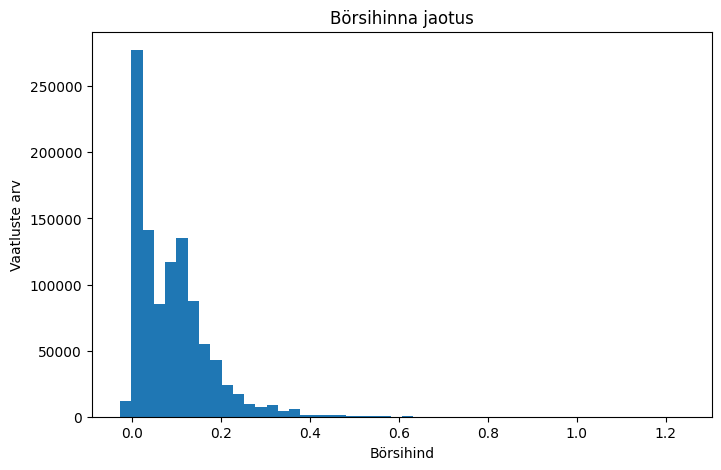

In [106]:
plt.figure(figsize=(8, 5))

plt.hist(df_price["price"], bins=50)

plt.xlabel("Börsihind")
plt.ylabel("Vaatluste arv")
plt.title("Börsihinna jaotus")
plt.show()

In [105]:
df_price["price"].describe().round(4)

count    1.038048e+06
mean     8.740000e-02
std      8.560000e-02
min     -2.650000e-02
25%      1.850000e-02
50%      7.560000e-02
75%      1.278000e-01
max      1.240000e+00
Name: price, dtype: float64

## 16. Börsihinna ja tarbimise korrelatsioon segmentide lõikes

Järgnevalt arvutatakse iga kliendisegmendi kohta Pearsoni korrelatsioonikordaja börsihinna ja 15-minutilise elektritarbimise vahel. Korrelatsioonikordaja näitab, kas kõrgem hind on seotud suurema või väiksema tarbimisega.

Negatiivne korrelatsioon tähendab, et kõrgema hinna korral on tarbimine pigem väiksem. Positiivne korrelatsioon tähendab, et kõrgema hinna korral on tarbimine pigem suurem. Nullilähedane korrelatsioon viitab sellele, et hinna ja tarbimise vahel puudub tugev lineaarne seos.

In [107]:
price_correlation = (
    df_price.groupby("segment", observed=False)
    .apply(lambda x: x["consumption_kwh"].corr(x["price"]))
    .reset_index(name="price_consumption_correlation")
)

price_correlation["segment"] = pd.Categorical(
    price_correlation["segment"],
    categories=segment_order,
    ordered=True
)

price_correlation = price_correlation.sort_values("segment").reset_index(drop=True)

price_correlation

,segment,price_consumption_correlation
0,s,-0.029676
1,m,0.012245
2,l,-0.059815
3,xl,-0.041946


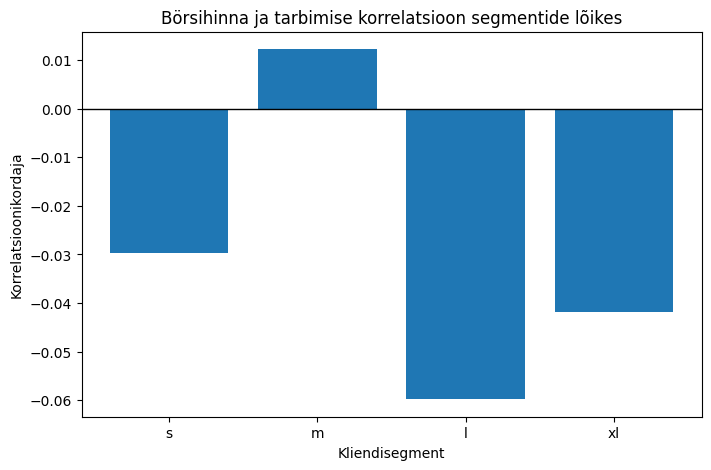

In [108]:
plt.figure(figsize=(8, 5))

plt.bar(
    price_correlation["segment"],
    price_correlation["price_consumption_correlation"]
)

plt.axhline(0, color="black", linewidth=1)

plt.xlabel("Kliendisegment")
plt.ylabel("Korrelatsioonikordaja")
plt.title("Börsihinna ja tarbimise korrelatsioon segmentide lõikes")
plt.show()

Graafikul on esitatud börsihinna ja 15-minutilise elektritarbimise korrelatsioon kliendisegmentide lõikes. Korrelatsioonikordaja näitab, kas kõrgema börsihinna korral on tarbimine pigem suurem või väiksem.

Tulemuste põhjal on näha, et kõigis segmentides on korrelatsioon väga nõrk. Segmentides `s`, `l` ja `xl` on korrelatsioon negatiivne, mis tähendab, et kõrgema börsihinna korral on tarbimine nendes segmentides mõnevõrra väiksem. Kõige tugevam negatiivne seos esineb segmendis `l`, kuid ka selle väärtus on väike.

Segment `m` erineb teistest, kuna selle korrelatsioon on kergelt positiivne. See tähendab, et selles segmendis ei ole näha tarbimise vähenemist kõrgema hinna korral. Kuna väärtus on siiski väga lähedal nullile, ei saa seda pidada tugevaks seoseks.

Elektripakkuja vaates tähendab see, et kliendid ei paista oma tarbimist börsihinna muutuste järgi selgelt kohandavat. Kõrgema hinna korral ei ole näha tugevat tarbimise langust ning madalama hinna korral ei ole näha selget tarbimise suurenemist. Seega viitab tulemus sellele, et tarbimist mõjutavad tõenäoliselt rohkem muud tegurid, näiteks kellaaeg, nädalapäev, hooaeg või tavapärased tarbimisharjumused.

## 17. Statistiline analüüs

Lisaks eksploratiivsele analüüsile viiakse läbi statistiline analüüs, et hinnata, kas kliendisegmentide vahelised erinevused ja börsihinna seos tarbimisega on statistiliselt olulised.

Statistilise analüüsi eesmärk on kontrollida järgmisi küsimusi:

1. Kas keskmine päevane elektritarbimine erineb kliendisegmentide vahel?
2. Kas tööpäevade ja nädalavahetuste tarbimine erineb?
3. Kas börsihinna ja elektritarbimise vahel on statistiliselt oluline seos?

Statistilise olulisuse hindamisel kasutatakse olulisuse nivood 0,05. Kui p-väärtus on väiksem kui 0,05, loetakse tulemus statistiliselt oluliseks.

In [109]:
from scipy import stats

In [110]:
daily_client.head()

,segment,household_id,date,daily_kwh
0,s,s-1,2025-04-01,0.667
1,s,s-1,2025-04-02,0.557
2,s,s-1,2025-04-03,0.573
3,s,s-1,2025-04-04,0.768
4,s,s-1,2025-04-05,0.586


## 18. Segmentide päevase tarbimise erinevuse testimine

Selles etapis kontrollitakse, kas päevane elektritarbimine erineb kliendisegmentide vahel statistiliselt olulisel määral.

Kuna päevase tarbimise jaotused võivad olla ebasümmeetrilised ja sisaldada erindväärtusi, kasutatakse Kruskal-Wallise testi. See test sobib mitme sõltumatu grupi võrdlemiseks juhul, kui normaaljaotuse eeldus ei pruugi olla täidetud.

Nullhüpotees: segmentide päevase tarbimise jaotused ei erine.

Alternatiivne hüpotees: vähemalt ühe segmendi päevane tarbimine erineb teistest.

In [112]:
groups = [
    daily_client[daily_client["segment"] == segment]["daily_kwh"].dropna()
    for segment in segment_order
]

kruskal_result = stats.kruskal(*groups)

print("Kruskal-Wallise testi tulemus")
print("Statistik:", round(kruskal_result.statistic, 4))
print("p-väärtus:", kruskal_result.pvalue)

Kruskal-Wallise testi tulemus
Statistik: 4524.6141
p-väärtus: 0.0


In [113]:
if kruskal_result.pvalue < 0.05:
    print("Tulemus on statistiliselt oluline: segmentide päevane tarbimine erineb.")
else:
    print("Tulemus ei ole statistiliselt oluline: segmentide päevase tarbimise erinevust ei tuvastatud.")

Tulemus on statistiliselt oluline: segmentide päevane tarbimine erineb.


## 19. Segmentide paarikaupa võrdlus

Kuna Kruskal-Wallise test näitab ainult seda, kas vähemalt üks segment erineb teistest, tehakse täiendavalt paarikaupa võrdlused segmentide vahel. Selleks kasutatakse Mann-Whitney U testi.

Paarikaupa võrdluste puhul korrigeeritakse p-väärtusi Bonferroni meetodiga, et vähendada juhusliku statistilise olulisuse riski.

In [115]:
from itertools import combinations

pairwise_results = []

for seg1, seg2 in combinations(segment_order, 2):
    data1 = daily_client[daily_client["segment"] == seg1]["daily_kwh"].dropna()
    data2 = daily_client[daily_client["segment"] == seg2]["daily_kwh"].dropna()
    
    result = stats.mannwhitneyu(data1, data2, alternative="two-sided")
    
    pairwise_results.append({
        "segment_1": seg1,
        "segment_2": seg2,
        "u_statistic": result.statistic,
        "p_value": result.pvalue
    })

pairwise_results = pd.DataFrame(pairwise_results)

# Bonferroni korrektsioon
pairwise_results["p_value_corrected"] = (
    pairwise_results["p_value"] * len(pairwise_results)
)

pairwise_results["p_value_corrected"] = pairwise_results["p_value_corrected"].clip(upper=1)

pairwise_results["significant"] = pairwise_results["p_value_corrected"] < 0.05

pairwise_results

,segment_1,segment_2,u_statistic,p_value,p_value_corrected,significant
0,s,m,3410230.5,1.555019e-166,9.330116e-166,True
1,s,l,2022792.0,0.000000e+00,0.000000e+00,True
2,s,xl,1234116.0,0.000000e+00,0.000000e+00,True
3,m,l,3336492.5,5.135491e-144,3.081295e-143,True
4,m,xl,1943676.0,0.000000e+00,0.000000e+00,True
5,l,xl,3142064.0,4.441558e-174,2.664935e-173,True


## 20. Tööpäeva ja nädalavahetuse tarbimise erinevuse testimine

Järgnevalt kontrollitakse, kas päevane elektritarbimine erineb tööpäevade (`weekday`) ja nädalavahetuste (`weekend`) vahel. Test tehakse iga kliendisegmendi kohta eraldi.

Kuna võrreldakse kahte sõltumatut gruppi ning tarbimisandmed võivad olla ebasümmeetrilised, kasutatakse Mann-Whitney U testi.

In [116]:
weekday_weekend_tests = []

for segment in segment_order:
    segment_data = weekday_weekend[weekday_weekend["segment"] == segment]
    
    weekday_data = segment_data[segment_data["is_weekend"] == False]["daily_kwh"].dropna()
    weekend_data = segment_data[segment_data["is_weekend"] == True]["daily_kwh"].dropna()
    
    result = stats.mannwhitneyu(
        weekday_data,
        weekend_data,
        alternative="two-sided"
    )
    
    weekday_weekend_tests.append({
        "segment": segment,
        "weekday_mean": weekday_data.mean(),
        "weekend_mean": weekend_data.mean(),
        "u_statistic": result.statistic,
        "p_value": result.pvalue,
        "significant": result.pvalue < 0.05
    })

weekday_weekend_tests = pd.DataFrame(weekday_weekend_tests)

weekday_weekend_tests

,segment,weekday_mean,weekend_mean,u_statistic,p_value,significant
0,s,11.636096,12.325158,1108827.5,0.293256,False
1,m,17.008487,18.354957,1084376.5,0.043033,True
2,l,27.182764,31.761744,901813.5,0.000002,True
3,xl,50.507162,55.601214,1060671.5,0.003015,True


In [117]:
price_correlation_tests = []

for segment in segment_order:
    segment_data = df_price[df_price["segment"] == segment][["price", "consumption_kwh"]].dropna()
    
    corr, p_value = stats.pearsonr(
        segment_data["price"],
        segment_data["consumption_kwh"]
    )
    
    price_correlation_tests.append({
        "segment": segment,
        "correlation": corr,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

price_correlation_tests = pd.DataFrame(price_correlation_tests)

price_correlation_tests

,segment,correlation,p_value,significant
0,s,-0.029676,1.616298e-52,True
1,m,0.012245,3.136378e-10,True
2,l,-0.059815,8.552362e-194,True
3,xl,-0.041946,4.104069e-103,True
